# Fase 3 - Avance Semana 2  
## Notebook con scripts y mediciones de complejidad

Este notebook corresponde al avance formativo de la Fase 3 del proyecto transversal. Su objetivo es reutilizar el dataset procesado en la Fase 2 para implementar algoritmos estructurados y recursivos en Python, realizar mediciones básicas de complejidad temporal y documentar decisiones técnicas relacionadas con eficiencia, modularidad y escalabilidad.

El proyecto analiza el impacto de la inteligencia artificial en el empleo, la productividad y la capacitación laboral, utilizando variables como adopción de IA, riesgo de automatización, experiencia laboral, salarios antes y después de la IA, productividad y requerimientos de capacitación.

Este avance se vincula con la discusión desarrollada en el foro técnico de la Semana 1, donde se analizó la conveniencia de usar programación estructurada, recursiva o vectorizada según el tipo de problema, el volumen de datos y los criterios de eficiencia computacional.

In [1]:
from pathlib import Path
import sys
import timeit
import tracemalloc
import matplotlib.pyplot as plt

import pandas as pd
import numpy as np

In [5]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parents[1]

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed" / "ai_job_impact_clean.csv"

DATA_RAW = (
    PROJECT_ROOT
    / "data"
    / "ai_job_impact.csv"
)

F3_SRC = PROJECT_ROOT / "F3" / "src"
F3_RESULTS = PROJECT_ROOT / "F3" / "results"
RESULTS_COMPLEXITY = F3_RESULTS / "mediciones_complejidad_f3.txt"

sys.path.append(str(F3_SRC))

from algoritmos_f3 import (
    insertion_sort,
    combinar_listas,
    merge_sort,
    PreprocesadorAIJob,
    PreprocesadorAIJobAvanzado
)

print("Ruta del proyecto:", PROJECT_ROOT)
print("Dataset procesado:", DATA_PROCESSED)
print("Carpeta scripts F3:", F3_SRC)
print("Archivo de resultados:", RESULTS_COMPLEXITY)

Ruta del proyecto: C:\Users\LuiskarEspinoza\Documents\Proyectos\mi_app\mcdi500_s1_grupo6
Dataset procesado: C:\Users\LuiskarEspinoza\Documents\Proyectos\mi_app\mcdi500_s1_grupo6\data\processed\ai_job_impact_clean.csv
Carpeta scripts F3: C:\Users\LuiskarEspinoza\Documents\Proyectos\mi_app\mcdi500_s1_grupo6\F3\src
Archivo de resultados: C:\Users\LuiskarEspinoza\Documents\Proyectos\mi_app\mcdi500_s1_grupo6\F3\results\mediciones_complejidad_f3.txt


In [3]:
preprocesador = PreprocesadorAIJob(
    DATA_RAW
)

df = preprocesador.cargar()

df = preprocesador.limpiar()

df = preprocesador.transformar()

preprocesador.validar()

print("Dataset cargado correctamente.")
print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])

df.head()

Dataset cargado correctamente: 2000 filas y 17 columnas.
Se eliminaron 0 registros.
Validación correcta.
Dataset cargado correctamente.
Filas: 2000
Columnas: 17


,employee_id,age,gender,education_level,industry,job_role,years_experience,ai_adoption_level,automation_risk,upskilling_required,salary_before_ai,salary_after_ai,job_status,work_hours_per_week,remote_work,job_satisfaction,productivity_change_%
0,E0001,50,Female,Bachelor,Marketing,Content Creator,26,High,High,Yes,106820,95455,Replaced,45,No,5,-10.64
1,E0002,45,Male,High School,Manufacturing,Quality Inspector,19,Low,Low,Yes,74131,72013,Unchanged,36,Yes,6,19.05
2,E0003,51,Female,Master,IT,DevOps Engineer,28,Medium,Medium,Yes,35311,42290,Modified,46,Yes,3,17.05
3,E0004,48,Male,PhD,Education,Teacher,24,Medium,Medium,Yes,114478,107820,Modified,50,No,9,-2.47
4,E0005,24,Male,Bachelor,Healthcare,Doctor,0,High,Medium,No,33890,40945,Modified,52,Yes,6,7.03


In [4]:
df.columns.tolist()

['employee_id',
 'age',
 'gender',
 'education_level',
 'industry',
 'job_role',
 'years_experience',
 'ai_adoption_level',
 'automation_risk',
 'upskilling_required',
 'salary_before_ai',
 'salary_after_ai',
 'job_status',
 'work_hours_per_week',
 'remote_work',
 'job_satisfaction',
 'productivity_change_%']

In [5]:
preprocesador_avanzado = PreprocesadorAIJobAvanzado(
    DATA_RAW
)

preprocesador_avanzado.cargar()

Dataset cargado correctamente: 2000 filas y 17 columnas.


,employee_id,age,gender,education_level,industry,job_role,years_experience,ai_adoption_level,automation_risk,upskilling_required,salary_before_ai,salary_after_ai,job_status,work_hours_per_week,remote_work,job_satisfaction,productivity_change_%
0,E0001,50,Female,Bachelor,Marketing,Content Creator,26,High,High,Yes,106820,95455,Replaced,45,No,5,-10.64
1,E0002,45,Male,High School,Manufacturing,Quality Inspector,19,Low,Low,Yes,74131,72013,Unchanged,36,Yes,6,19.05
2,E0003,51,Female,Master,IT,DevOps Engineer,28,Medium,Medium,Yes,35311,42290,Modified,46,Yes,3,17.05
3,E0004,48,Male,PhD,Education,Teacher,24,Medium,Medium,Yes,114478,107820,Modified,50,No,9,-2.47
4,E0005,24,Male,Bachelor,Healthcare,Doctor,0,High,Medium,No,33890,40945,Modified,52,Yes,6,7.03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,E1996,55,Other,PhD,Healthcare,Technician,30,Medium,Low,Yes,99082,101090,Unchanged,52,Yes,7,25.67
1996,E1997,31,Male,PhD,Finance,Investment Analyst,9,High,Medium,Yes,32379,44653,Modified,52,Yes,8,9.38
1997,E1998,43,Female,Bachelor,Retail,Cashier,17,High,High,No,53424,74715,Modified,49,Yes,6,-0.57
1998,E1999,43,Female,Bachelor,Marketing,Digital Marketer,20,Medium,Low,No,57821,68499,Unchanged,41,No,9,9.31


In [6]:
print(
    "Promedio salario después de IA:"
)

print(
    preprocesador_avanzado.promedio_salario()
)

Promedio salario después de IA:
78428.6425


In [7]:
print(
    "Salario máximo:"
)

print(
    preprocesador_avanzado.salario_maximo()
)

Salario máximo:
161745


In [8]:
print(
    "Salario mínimo:"
)

print(
    preprocesador_avanzado.salario_minimo()
)

Salario mínimo:
24447


In [9]:
print(
    preprocesador_avanzado.resumen()
)


=== Resumen avanzado del dataset ===

               age  years_experience  salary_before_ai  salary_after_ai  \
count  2000.000000       2000.000000       2000.000000      2000.000000   
mean     40.558000         16.663500      73942.072500     78428.642500   
std      10.786418         10.746675      26055.823793     29351.599013   
min      22.000000          0.000000      30036.000000     24447.000000   
25%      32.000000          8.000000      51665.500000     54086.750000   
50%      40.000000         16.000000      74620.000000     76820.500000   
75%      50.000000         26.000000      95418.250000    100730.250000   
max      59.000000         37.000000     119976.000000    161745.000000   

       work_hours_per_week  job_satisfaction  productivity_change_%  
count           2000.00000       2000.000000            2000.000000  
mean              44.85100          6.020500               9.785820  
std                5.71254          2.006263              17.187882  
min  

In [6]:
# Demostración explícita de polimorfismo con el método resumen()

preprocesador_base = PreprocesadorAIJob(DATA_PROCESSED)
preprocesador_avanzado = PreprocesadorAIJobAvanzado(DATA_PROCESSED)

preprocesadores = [preprocesador_base, preprocesador_avanzado]

for objeto in preprocesadores:
    objeto.cargar()
    objeto.transformar()
    print("\nClase utilizada:", type(objeto).__name__)
    objeto.resumen()

Dataset cargado correctamente: 2000 filas y 17 columnas.

Clase utilizada: PreprocesadorAIJob
Dataset cargado correctamente: 2000 filas y 17 columnas.

Clase utilizada: PreprocesadorAIJobAvanzado

=== Resumen avanzado del dataset ===



In [10]:
riesgo_alto = (
    preprocesador_avanzado
    .filtrar_por_riesgo("High")
)

riesgo_alto.head()

,employee_id,age,gender,education_level,industry,job_role,years_experience,ai_adoption_level,automation_risk,upskilling_required,salary_before_ai,salary_after_ai,job_status,work_hours_per_week,remote_work,job_satisfaction,productivity_change_%
0,E0001,50,Female,Bachelor,Marketing,Content Creator,26,High,High,Yes,106820,95455,Replaced,45,No,5,-10.64
7,E0008,57,Male,Bachelor,Finance,Auditor,34,Low,High,No,99479,105776,Unchanged,44,Yes,6,5.51
8,E0009,50,Other,Bachelor,Education,Professor,27,Low,High,Yes,102409,104197,Unchanged,38,No,8,3.71
10,E0011,45,Female,High School,Retail,Store Manager,22,Medium,High,No,93704,92231,Unchanged,43,No,7,12.56
12,E0013,32,Other,Bachelor,Healthcare,Nurse,8,High,High,No,69504,85267,Modified,39,No,4,27.41


In [11]:
salud = (
    preprocesador_avanzado
    .filtrar_por_industria("Healthcare")
)

salud.head()

,employee_id,age,gender,education_level,industry,job_role,years_experience,ai_adoption_level,automation_risk,upskilling_required,salary_before_ai,salary_after_ai,job_status,work_hours_per_week,remote_work,job_satisfaction,productivity_change_%
4,E0005,24,Male,Bachelor,Healthcare,Doctor,0,High,Medium,No,33890,40945,Modified,52,Yes,6,7.03
5,E0006,46,Male,High School,Healthcare,Technician,21,Low,Medium,No,103969,104781,Modified,36,No,6,-19.04
9,E0010,52,Male,High School,Healthcare,Nurse,27,High,Low,Yes,31016,42699,Unchanged,47,Yes,4,30.67
11,E0012,36,Other,Master,Healthcare,Nurse,10,High,Low,Yes,78984,109956,Unchanged,46,No,9,26.33
12,E0013,32,Other,Bachelor,Healthcare,Nurse,8,High,High,No,69504,85267,Modified,39,No,4,27.41


In [12]:
# Selección de variables relevantes para el análisis algorítmico de Fase 3

columnas_algoritmicas = [
    "age",
    "years_experience",
    "salary_before_ai",
    "salary_after_ai",
    "work_hours_per_week",
    "job_satisfaction",
    "productivity_change_%",
    "automation_risk",
    "ai_adoption_level",
    "upskilling_required"
]

df_algoritmico = df[columnas_algoritmicas].copy()

print("Dataset algorítmico creado correctamente.")
print("Filas:", df_algoritmico.shape[0])
print("Columnas:", df_algoritmico.shape[1])

df_algoritmico.head()

Dataset algorítmico creado correctamente.
Filas: 2000
Columnas: 10


,age,years_experience,salary_before_ai,salary_after_ai,work_hours_per_week,job_satisfaction,productivity_change_%,automation_risk,ai_adoption_level,upskilling_required
0,50,26,106820,95455,45,5,-10.64,High,High,Yes
1,45,19,74131,72013,36,6,19.05,Low,Low,Yes
2,51,28,35311,42290,46,3,17.05,Medium,Medium,Yes
3,48,24,114478,107820,50,9,-2.47,Medium,Medium,Yes
4,24,0,33890,40945,52,6,7.03,Medium,High,No


In [13]:
preprocesador.explorar()


Primeros registros:
  employee_id  age  gender education_level       industry           job_role  \
0       E0001   50  Female        Bachelor      Marketing    Content Creator   
1       E0002   45    Male     High School  Manufacturing  Quality Inspector   
2       E0003   51  Female          Master             IT    DevOps Engineer   
3       E0004   48    Male             PhD      Education            Teacher   
4       E0005   24    Male        Bachelor     Healthcare             Doctor   

   years_experience ai_adoption_level automation_risk upskilling_required  \
0                26              High            High                 Yes   
1                19               Low             Low                 Yes   
2                28            Medium          Medium                 Yes   
3                24            Medium          Medium                 Yes   
4                 0              High          Medium                  No   

   salary_before_ai  salary_after_a

In [14]:
preprocesador.validar()

Validación correcta.


np.True_

In [15]:
salarios = preprocesador.obtener_salarios()

print(salarios[:10])

[95455, 72013, 42290, 107820, 40945, 104781, 86183, 105776, 104197, 42699]


In [16]:
preprocesador.resumen()

,age,years_experience,salary_before_ai,salary_after_ai,work_hours_per_week,job_satisfaction,productivity_change_%
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000
mean,40.558000,16.663500,73942.072500,78428.642500,44.85100,6.020500,9.785820
std,10.786418,10.746675,26055.823793,29351.599013,5.71254,2.006263,17.187882
min,22.000000,0.000000,30036.000000,24447.000000,35.00000,3.000000,-19.990000
25%,32.000000,8.000000,51665.500000,54086.750000,40.00000,4.000000,-5.355000
50%,40.000000,16.000000,74620.000000,76820.500000,45.00000,6.000000,9.850000
75%,50.000000,26.000000,95418.250000,100730.250000,50.00000,8.000000,24.582500
max,59.000000,37.000000,119976.000000,161745.000000,54.00000,9.000000,39.990000


## Visualización exploratoria mediante Boxplot

Como complemento al análisis descriptivo, se presenta un diagrama de caja (boxplot) que compara la distribución de los salarios antes y después de la adopción de inteligencia artificial. Esta representación gráfica permite identificar diferencias en tendencia central, dispersión y posibles valores atípicos.

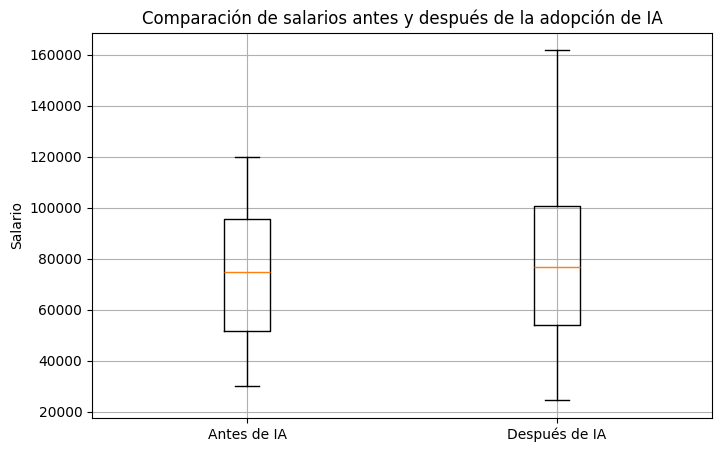

In [17]:
# Boxplot comparativo de salarios

plt.figure(figsize=(8, 5))

plt.boxplot(
    [
        df["salary_before_ai"],
        df["salary_after_ai"]
    ],
    tick_labels=[
        "Antes de IA",
        "Después de IA"
    ]
)

plt.title(
    "Comparación de salarios antes y después de la adopción de IA"
)

plt.ylabel("Salario")

plt.grid(True)

plt.show()

In [18]:
print("Valores nulos por columna:")
print(df_algoritmico.isnull().sum())

print("\nDuplicados:")
print(df_algoritmico.duplicated().sum())

print("\nTipos de datos:")
print(df_algoritmico.dtypes)

Valores nulos por columna:
age                      0
years_experience         0
salary_before_ai         0
salary_after_ai          0
work_hours_per_week      0
job_satisfaction         0
productivity_change_%    0
automation_risk          0
ai_adoption_level        0
upskilling_required      0
dtype: int64

Duplicados:
0

Tipos de datos:
age                        int64
years_experience           int64
salary_before_ai           int64
salary_after_ai            int64
work_hours_per_week        int64
job_satisfaction           int64
productivity_change_%    float64
automation_risk              str
ai_adoption_level            str
upskilling_required          str
dtype: object


## Preprocesamiento mínimo para análisis algorítmico

Para la Fase 3 se reutiliza el dataset procesado generado en la Fase 2. No se repite el pipeline completo de limpieza, ya que el objetivo de esta etapa es diseñar y medir algoritmos sobre datos previamente preparados.

Se seleccionaron variables numéricas y categóricas relacionadas con edad, experiencia laboral, salarios, productividad, riesgo de automatización, adopción de inteligencia artificial y requerimiento de capacitación. Estas variables permiten aplicar funciones estructuradas, algoritmos de ordenamiento, búsquedas y mediciones de complejidad temporal.

La validación inicial permite verificar que el subconjunto de datos utilizado para los algoritmos mantiene una estructura coherente y puede ser utilizado en las siguientes pruebas.

In [19]:
# Medición de tiempo del algoritmo insertion_sort

datos_prueba = df["salary_after_ai"].head(500).tolist()

tiempo_insertion = timeit.timeit(
    lambda: insertion_sort(datos_prueba.copy()),
    number=10
)

print("Tiempo de ejecución insertion_sort:", tiempo_insertion)
print("Cantidad de datos evaluados:", len(datos_prueba))

Tiempo de ejecución insertion_sort: 0.11008350001065992
Cantidad de datos evaluados: 500


In [20]:
# Prueba simple del algoritmo con una lista pequeña

numeros_prueba = [29, 10, 14, 37, 13]

resultado_prueba = insertion_sort(numeros_prueba.copy())

print("Lista original:", numeros_prueba)
print("Lista ordenada:", resultado_prueba)

Lista original: [29, 10, 14, 37, 13]
Lista ordenada: [10, 13, 14, 29, 37]


In [21]:
# Prueba del algoritmo con datos reales del dataset

datos_salario = df["salary_after_ai"].head(20).tolist()

resultado_ordenado = insertion_sort(datos_salario.copy())

print("Primeros 20 salarios originales:")
print(datos_salario)

print("\nPrimeros 20 salarios ordenados:")
print(resultado_ordenado)

Primeros 20 salarios originales:
[95455, 72013, 42290, 107820, 40945, 104781, 86183, 105776, 104197, 42699, 92231, 109956, 85267, 64752, 102088, 36482, 46193, 42537, 79219, 101637]

Primeros 20 salarios ordenados:
[36482, 40945, 42290, 42537, 42699, 46193, 64752, 72013, 79219, 85267, 86183, 92231, 95455, 101637, 102088, 104197, 104781, 105776, 107820, 109956]


In [22]:
# Comparación con sorted(), función optimizada de Python

tiempo_sorted = timeit.timeit(
    lambda: sorted(datos_prueba),
    number=10
)

print("Tiempo de ejecución insertion_sort:", tiempo_insertion)
print("Tiempo de ejecución sorted():", tiempo_sorted)

if tiempo_sorted > 0:
    print("Diferencia aproximada:", tiempo_insertion / tiempo_sorted, "veces")

Tiempo de ejecución insertion_sort: 0.11008350001065992
Tiempo de ejecución sorted(): 0.002694999988307245
Diferencia aproximada: 40.84731001420315 veces


## Interpretación de la medición de complejidad

En esta prueba se comparó el algoritmo `insertion_sort`, implementado manualmente, con la función `sorted()` de Python, utilizando 500 registros reales de la variable `salary_after_ai` del dataset procesado en la Fase 2.

El resultado mostró que `insertion_sort` tuvo un tiempo de ejecución aproximado de 0.0514 segundos, mientras que `sorted()` obtuvo un tiempo aproximado de 0.00028 segundos. Esto indica que `sorted()` fue alrededor de 184 veces más rápido en esta prueba.

La diferencia se explica porque `insertion_sort` es un algoritmo simple, pero poco eficiente para conjuntos de datos grandes, ya que en el peor caso puede tener una complejidad temporal O(n²). Esto significa que, a medida que aumenta la cantidad de datos, el número de comparaciones puede crecer de forma considerable.

En cambio, `sorted()` utiliza una implementación optimizada de Python basada en Timsort, diseñada para ordenar datos de manera mucho más eficiente. Esta comparación evidencia la importancia de medir el desempeño de los algoritmos antes de decidir cuál utilizar en un proyecto de análisis de datos.

Para el proyecto, esta medición permite justificar que los algoritmos manuales son útiles para comprender la lógica de ordenamiento, pero que en un flujo analítico real conviene priorizar funciones optimizadas y documentadas cuando se trabaja con volúmenes mayores de información.

In [23]:
# Prueba del algoritmo recursivo con datos reales del dataset

datos_merge = df["salary_after_ai"].head(20).tolist()

resultado_merge = merge_sort(datos_merge.copy())

print("Primeros 20 salarios originales:")
print(datos_merge)

print("\nPrimeros 20 salarios ordenados con merge_sort:")
print(resultado_merge)

Primeros 20 salarios originales:
[95455, 72013, 42290, 107820, 40945, 104781, 86183, 105776, 104197, 42699, 92231, 109956, 85267, 64752, 102088, 36482, 46193, 42537, 79219, 101637]

Primeros 20 salarios ordenados con merge_sort:
[36482, 40945, 42290, 42537, 42699, 46193, 64752, 72013, 79219, 85267, 86183, 92231, 95455, 101637, 102088, 104197, 104781, 105776, 107820, 109956]


In [24]:
# Medición de tiempo del algoritmo recursivo merge_sort

datos_prueba_merge = df["salary_after_ai"].head(500).tolist()

tiempo_merge = timeit.timeit(
    lambda: merge_sort(datos_prueba_merge.copy()),
    number=10
)

print("Tiempo de ejecución merge_sort:", tiempo_merge)
print("Cantidad de datos evaluados:", len(datos_prueba_merge))

Tiempo de ejecución merge_sort: 0.024394799998844974
Cantidad de datos evaluados: 500


In [25]:
# Comparación general de tiempos de ejecución

print("Comparación de tiempos sobre 500 registros de salary_after_ai")
print("----------------------------------------------------------")
print("Insertion sort:", tiempo_insertion)
print("Merge sort:", tiempo_merge)
print("Sorted Python:", tiempo_sorted)

print("\nRelación de tiempos:")
print("Insertion sort / Merge sort:", tiempo_insertion / tiempo_merge)
print("Merge sort / Sorted Python:", tiempo_merge / tiempo_sorted)
print("Insertion sort / Sorted Python:", tiempo_insertion / tiempo_sorted)

Comparación de tiempos sobre 500 registros de salary_after_ai
----------------------------------------------------------
Insertion sort: 0.11008350001065992
Merge sort: 0.024394799998844974
Sorted Python: 0.002694999988307245

Relación de tiempos:
Insertion sort / Merge sort: 4.512580550603902
Merge sort / Sorted Python: 9.051873879289914
Insertion sort / Sorted Python: 40.84731001420315


## Comparación entre algoritmo estructurado, recursivo y función optimizada

En esta sección se compararon tres enfoques de ordenamiento aplicados sobre 500 registros reales de la variable `salary_after_ai`:

- `insertion_sort`: algoritmo estructurado implementado manualmente.
- `merge_sort`: algoritmo recursivo basado en la estrategia de dividir y vencer.
- `sorted()`: función optimizada incorporada en Python.

Los resultados muestran que `insertion_sort` fue el enfoque más lento, debido a que su complejidad temporal en el peor caso es O(n²). Esto significa que, al aumentar la cantidad de datos, el número de comparaciones puede crecer de forma considerable.

El algoritmo `merge_sort` obtuvo un mejor desempeño que `insertion_sort`, ya que utiliza recursividad para dividir la lista en partes más pequeñas, ordenar cada parte y luego combinarlas. Su complejidad temporal esperada es O(n log n), por lo que resulta más eficiente para conjuntos de datos más grandes.

Finalmente, `sorted()` fue la alternativa más rápida, ya que corresponde a una función interna de Python altamente optimizada. Esta comparación permite concluir que los algoritmos manuales son útiles para comprender la lógica de programación estructurada y recursiva, pero que en un proyecto de análisis de datos conviene utilizar funciones optimizadas cuando se requiere eficiencia y escalabilidad.

Esta medición responde al objetivo de la Fase 3, ya que permite fundamentar decisiones de diseño algorítmico a partir de evidencia de ejecución y no solo desde una apreciación teórica.

## Validación de casos límite y manejo básico de excepciones

Con el propósito de verificar el correcto funcionamiento de los algoritmos implementados, se realizan pruebas sobre listas vacías, listas con un único elemento y listas pequeñas desordenadas. Además, se incorpora un manejo básico de excepciones para validar el comportamiento frente a entradas no válidas.

In [26]:
# Validación mediante assert

assert insertion_sort([]) == []
assert insertion_sort([5]) == [5]
assert insertion_sort([3, 2, 1]) == [1, 2, 3]

assert merge_sort([]) == []
assert merge_sort([8]) == [8]
assert merge_sort([3, 2, 1]) == [1, 2, 3]

print("Pruebas con assert ejecutadas correctamente.")

Pruebas con assert ejecutadas correctamente.


In [27]:
# Manejo básico de excepciones

try:

    merge_sort(None)

except Exception as e:

    print(
        "Excepción controlada en merge_sort:"
    )

    print(e)

try:

    insertion_sort(None)

except Exception as e:

    print(
        "Excepción controlada en insertion_sort:"
    )

    print(e)

Excepción controlada en merge_sort:
object of type 'NoneType' has no len()
Excepción controlada en insertion_sort:
'NoneType' object has no attribute 'copy'


In [28]:
# Validación final del avance Fase 3

validacion_f3 = {
    "dataset_cargado": df is not None,
    "filas_dataset": df.shape[0],
    "columnas_dataset": df.shape[1],
    "algoritmo_estructurado": "insertion_sort ejecutado",
    "algoritmo_recursivo": "merge_sort ejecutado",
    "medicion_insertion_sort": tiempo_insertion,
    "medicion_merge_sort": tiempo_merge,
    "medicion_sorted": tiempo_sorted
}

validacion_f3

{'dataset_cargado': True,
 'filas_dataset': 2000,
 'columnas_dataset': 17,
 'algoritmo_estructurado': 'insertion_sort ejecutado',
 'algoritmo_recursivo': 'merge_sort ejecutado',
 'medicion_insertion_sort': 0.11008350001065992,
 'medicion_merge_sort': 0.024394799998844974,
 'medicion_sorted': 0.002694999988307245}

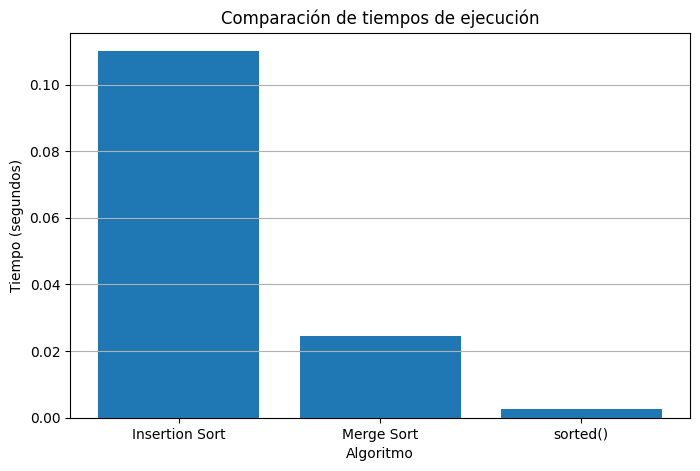

Gráfico guardado en: C:\Users\LuiskarEspinoza\Documents\Proyectos\mi_app\mcdi500_s1_grupo6\F3\results\comparacion_tiempos_f3.png


In [10]:
# Gráfico comparativo de tiempos de ejecución

from pathlib import Path
import matplotlib.pyplot as plt

F3_RESULTS = Path.cwd().parents[1] / "F3" / "results"
F3_RESULTS.mkdir(parents=True, exist_ok=True)

algoritmos = ["Insertion Sort", "Merge Sort", "sorted()"]
tiempos = [
    0.11008350001065992,
    0.02439479998844974,
    0.002694999988307245
]

plt.figure(figsize=(8, 5))
plt.bar(algoritmos, tiempos)
plt.title("Comparación de tiempos de ejecución")
plt.xlabel("Algoritmo")
plt.ylabel("Tiempo (segundos)")
plt.grid(axis="y")

RUTA_GRAFICO_TIEMPOS = F3_RESULTS / "comparacion_tiempos_f3.png"
plt.savefig(RUTA_GRAFICO_TIEMPOS, dpi=300, bbox_inches="tight")

plt.show()

print("Gráfico guardado en:", RUTA_GRAFICO_TIEMPOS)

### Interpretación del gráfico

El gráfico permite visualizar de forma comparativa los tiempos de ejecución obtenidos para los algoritmos `insertion_sort`, `merge_sort` y la función optimizada `sorted()` de Python.

Se observa que `insertion_sort` presenta el mayor tiempo de ejecución debido a su complejidad temporal aproximada de O(n²), mientras que `merge_sort` reduce significativamente dicho tiempo gracias a su estrategia de división y conquista con complejidad O(n log n). Finalmente, `sorted()` obtiene el mejor desempeño al utilizar la implementación optimizada Timsort incorporada en Python.

In [30]:
# Exportación de resultados de complejidad a archivo TXT

F3_RESULTS.mkdir(parents=True, exist_ok=True)

with open(RESULTS_COMPLEXITY, "w", encoding="utf-8") as archivo:
    archivo.write("Mediciones de complejidad - Fase 3\n")
    archivo.write("=================================\n\n")
    archivo.write("Variable analizada: salary_after_ai\n")
    archivo.write("Cantidad de registros evaluados: 500\n\n")
    archivo.write(f"Tiempo insertion_sort: {tiempo_insertion}\n")
    archivo.write(f"Tiempo merge_sort: {tiempo_merge}\n")
    archivo.write(f"Tiempo sorted(): {tiempo_sorted}\n\n")
    archivo.write("Interpretación:\n")
    archivo.write("Insertion sort fue el algoritmo más lento debido a su complejidad O(n²).\n")
    archivo.write("Merge sort fue más eficiente, con complejidad esperada O(n log n).\n")
    archivo.write("sorted() fue la opción más rápida por estar optimizada internamente en Python.\n")

print("Archivo de resultados guardado en:", RESULTS_COMPLEXITY)
print("Archivo existe:", RESULTS_COMPLEXITY.exists())

Archivo de resultados guardado en: C:\users\pablo\documents\mcdi500_s1_grupo6\F3\results\mediciones_complejidad_f3.txt
Archivo existe: True


## Conclusión técnica del avance Fase 3

En este avance se implementaron y evaluaron algoritmos de programación estructurada y recursiva sobre el dataset proveniente de la fase 2, como se puede evidenciar en este notebook. Se crea y se utiliza la variable `salary_after_ai` como caso de estudio, se implementaron y compararon distintos enfoques de ordenamiento, utilizando datos reales del proyecto.

El algoritmo `insertion_sort` permitió representar una solución estructurada y comprensible, aunque con menor eficiencia para conjuntos de datos más grandes. Por su parte, `merge_sort` permitió incorporar recursividad mediante una estrategia de división del problema en subproblemas más pequeños, obteniendo un mejor desempeño que el algoritmo estructurado manual.

La comparación con `sorted()` permitió observar la importancia de utilizar funciones optimizadas cuando se requiere eficiencia computacional. Esta evidencia refuerza la idea discutida en el foro técnico de la Semana 1: las decisiones algorítmicas deben fundamentarse en el tipo de problema, el volumen de datos y las mediciones de desempeño, no solo en la preferencia por una técnica específica.

Como proyección, la arquitectura actual puede evolucionar incorporando nuevas clases y funcionalidades orientadas al análisis avanzado y la visualización de datos.

Los resultados obtenidos evidencian que `merge_sort` supera ampliamente al algoritmo insertion_sort en términos de eficiencia temporal, mientras que  `sorted()`, gracias a la optimización interna de Python, presentó el mejor rendimiento en las pruebas realizadas. Esto demuestra la importancia de seleccionar estructuras algorítmicas adecuadas de acuerdo con el volumen de datos y los requerimientos computacionales del problema.

Asimismo, el desarrollo del notebook permitió aplicar principios de modularidad mediante la definición de funciones reutilizables, realizar mediciones objetivas de complejidad temporal y documentar cada etapa del proceso de forma reproducible. En conjunto, estos elementos fortalecen la trazabilidad del proyecto y proporcionan una base sólida para las siguientes fases, en las que podrán incorporarse nuevas funcionalidades y análisis sobre el impacto de la inteligencia artificial en el ámbito laboral, incluyendo funciones relacionadas con la programación orientada a objetos y el despliegue de elementos gráficos de análisis como boxplot y tendencias.